# Hypothesis Testing using Language Models
### Complete Assignment Solution

This notebook covers:
- **Q1**: Computing LM scores (log-prob, per-word log-prob, SLOR) using Trigram and Bigram models
- **Q2**: Spearman correlation between LM scores and human acceptability ratings
- **Q3**: Word length, frequency, information content analysis


## 0. Setup: Mount Google Drive and Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import subprocess

# ---------------------------------------------------------------
# CONFIGURE THESE PATHS to match your Google Drive folder layout
# ---------------------------------------------------------------
DRIVE_BASE     = '/content/drive/MyDrive/CP Assignment 7'          # root of your Drive
NGRAM_BIN      = f'{DRIVE_BASE}/ngram'             # ngram binary
NGRAM_COUNT_BIN= f'{DRIVE_BASE}/ngram-count'       # ngram-count binary
BROWN_DIR      = f'{DRIVE_BASE}/browndata'         # folder with train/dev/test

WORK_DIR = '/content/lm_work'
os.makedirs(WORK_DIR, exist_ok=True)

# Copy binaries to work dir and make them executable
for b in [NGRAM_BIN, NGRAM_COUNT_BIN]:
    dest = f'{WORK_DIR}/{os.path.basename(b)}'
    if not os.path.exists(dest):
        subprocess.run(['cp', b, dest], check=True)
    subprocess.run(['chmod', '+x', dest], check=True)

NGRAM      = f'{WORK_DIR}/ngram'
NGRAM_COUNT= f'{WORK_DIR}/ngram-count'

print('Binaries ready:', os.path.exists(NGRAM), os.path.exists(NGRAM_COUNT))

Binaries ready: True True


In [3]:
# Install Python dependencies
!pip install -q scipy pandas matplotlib numpy requests scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import re
import math
import requests
import string

print('All imports successful.')

All imports successful.


## 0.1  Download the BNC Dataset

In [4]:
# BNC_URL = 'https://gu-clasp.github.io/914a288ca1e127a7f1547412d9a7e056/bnc.csv'
BNC_PATH = f'{DRIVE_BASE}/bnc.csv'

# if not os.path.exists(BNC_PATH):
#     r = requests.get(BNC_URL)
#     with open(BNC_PATH, 'wb') as f:
#         f.write(r.content)
#     print('Downloaded BNC dataset.')
# else:
#     print('BNC dataset already present.')

bnc_df = pd.read_csv(BNC_PATH, sep = '\t')
print(bnc_df.shape)
bnc_df.head()

(5250, 6)


,MOP,language,text,length,rating_list,mean_rating
0,MOP2,en,"We've still got the Dower House , and Lincolns...",12,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.000000
1,MOP2,en,My first real friend was probably a boy called...,10,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.000000
2,MOP2,en,She was wearing denim overalls and carrying a ...,11,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.000000
3,MOP2,en,In the next year he had custody of Rochester C...,10,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 4, 4, 4, 4",3.812500
4,MOP2,en,BOOKING is essential for a cycle ride around W...,22,"4, 4, 4, 4, 4, 4, 1, 4, 1, 1, 4, 4, 1",3.076923


## 0.2  Inspect the Brown Corpus Files

In [5]:
TRAIN_FILE = f'{BROWN_DIR}/brown-train.txt'
DEV_FILE   = f'{BROWN_DIR}/brown-dev.txt'
TEST_FILE  = f'{BROWN_DIR}/brown-test.txt'

for f in [TRAIN_FILE, DEV_FILE, TEST_FILE]:
    lines = open(f).readlines()
    print(f'{f}: {len(lines)} lines')

/content/drive/MyDrive/CP Assignment 7/browndata/brown-train.txt: 37272 lines
/content/drive/MyDrive/CP Assignment 7/browndata/brown-dev.txt: 5734 lines
/content/drive/MyDrive/CP Assignment 7/browndata/brown-test.txt: 14335 lines


---
## Question 1: Training Language Models & Computing Scores

### 1.1  Train Unigram, Bigram, and Trigram LMs with Kneser-Ney

In [6]:
UNIGRAM_LM = f'{WORK_DIR}/unigram.lm'
BIGRAM_LM  = f'{WORK_DIR}/bigram.lm'
TRIGRAM_LM = f'{WORK_DIR}/trigram.lm'

def train_lm(order, output_path):
    cmd = [
        NGRAM_COUNT,
        '-order', str(order),
        '-kndiscount',          # Kneser-Ney interpolation
        '-interpolate',
        '-text', TRAIN_FILE,
        '-lm',  output_path
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('STDERR:', result.stderr)
    else:
        print(f'Trained {order}-gram LM -> {output_path}')

train_lm(1, UNIGRAM_LM)
train_lm(2, BIGRAM_LM)
train_lm(3, TRIGRAM_LM)

Trained 1-gram LM -> /content/lm_work/unigram.lm
Trained 2-gram LM -> /content/lm_work/bigram.lm
Trained 3-gram LM -> /content/lm_work/trigram.lm


### 1.2  Helper: Score a sentence with SRILM's ngram tool

In [7]:
import tempfile

def score_sentences_srilm(sentences, lm_path, order):
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as tmp:
        tmp_path = tmp.name
        for s in sentences:
            tmp.write(s.strip() + '\n')

    cmd = [NGRAM, '-order', str(order), '-lm', lm_path,
           '-ppl', tmp_path, '-debug', '2']
    result = subprocess.run(cmd, capture_output=True, text=True)
    os.unlink(tmp_path)

    # Print a sample of raw output to inspect
    sample_lines = result.stdout.split('\n')[:30]
    print("=== SRILM RAW OUTPUT SAMPLE ===")
    for l in sample_lines:
        print(repr(l))
    print("===")

    logprobs = []
    for line in result.stdout.split('\n'):
        line = line.strip()
        if 'logprob=' in line:
            # handles formats like: "logprob= -14.35" or "1 sentences, ... logprob= -14.35 ppl= ..."
            match = re.search(r'logprob=\s*([-\d.]+(?:e[+-]?\d+)?)', line)
            if match:
                lp = float(match.group(1))
                logprobs.append(lp if not math.isinf(lp) else float('nan'))

    return logprobs

# def score_sentences_srilm(sentences, lm_path, order):
#     """
#     Runs SRILM ngram to get per-sentence log10 probabilities.
#     Returns a list of log10(P) values (one per sentence).
#     Sentences with -inf are returned as NaN.
#     """
#     # Write sentences to a temp file
#     with tempfile.NamedTemporaryFile(mode='w', suffix='.txt',
#                                      delete=False) as tmp:
#         tmp_path = tmp.name
#         for s in sentences:
#             tmp.write(s.strip() + '\n')

#     cmd = [
#         NGRAM,
#         '-order', str(order),
#         '-lm', lm_path,
#         '-ppl', tmp_path,
#         '-debug', '2'   # per-sentence output
#     ]
#     result = subprocess.run(cmd, capture_output=True, text=True)
#     os.unlink(tmp_path)

#     logprobs = []
#     for line in result.stdout.split('\n'):
#         # Lines like: "logprob= -14.3556  ppl= 35.6"
#         if line.strip().startswith('logprob='):
#             parts = line.strip().split()
#             lp = float(parts[1])
#             logprobs.append(lp if not math.isinf(lp) else float('nan'))

#     return logprobs


def compute_scores(sentences, lm_path, unigram_lm_path, order):
    """
    Compute three scores per sentence:
      1. total_logprob     : log P(w1..n)
      2. avg_logprob       : (1/n) log P(w1..n)
      3. slor              : (log P_model - log P_unigram) / n
    All logs are base-10 from SRILM (converted to natural log equivalent
    for interpretation, but kept as log10 for correlation purposes).
    """
    model_lps   = score_sentences_srilm(sentences, lm_path,        order)
    unigram_lps = score_sentences_srilm(sentences, unigram_lm_path, 1)

    total_logprobs = []
    avg_logprobs   = []
    slors          = []

    for s, mlp, ulp in zip(sentences, model_lps, unigram_lps):
        words = s.strip().split()
        n = len(words)
        total_logprobs.append(mlp)
        avg_logprobs.append(mlp / n if n > 0 else float('nan'))
        slors.append((mlp - ulp) / n if n > 0 else float('nan'))

    return total_logprobs, avg_logprobs, slors

print('Helper functions defined.')

Helper functions defined.


### 1.3  Prepare BNC Sentences and Compute All Scores

In [8]:
# Inspect column names
print(bnc_df.columns.tolist())
bnc_df.head(3)

['MOP', 'language', 'text', 'length', 'rating_list', 'mean_rating']


,MOP,language,text,length,rating_list,mean_rating
0,MOP2,en,"We've still got the Dower House , and Lincolns...",12,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.0
1,MOP2,en,My first real friend was probably a boy called...,10,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.0
2,MOP2,en,She was wearing denim overalls and carrying a ...,11,"4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4",4.0


In [9]:
# Adjust column names below if your CSV differs
# Typical columns: 'sentence', 'rating' or 'mean_rating', 'std_rating' etc.
SENTENCE_COL = 'text'   # <-- change if needed
RATING_COL   = 'mean_rating'     # <-- change if needed (mean human acceptability)

# Show actual columns and pick correct ones
print(bnc_df.columns.tolist())

['MOP', 'language', 'text', 'length', 'rating_list', 'mean_rating']


In [10]:
# After confirming the correct column names above, set them here:
# e.g. SENTENCE_COL = 'sentence', RATING_COL = 'rating'

sentences    = bnc_df[SENTENCE_COL].astype(str).tolist()
human_ratings = bnc_df[RATING_COL].astype(float).tolist()

print(f'Total sentences: {len(sentences)}')
print('Sample:', sentences[0])
print('Rating:', human_ratings[0])

Total sentences: 5250
Sample: We've still got the Dower House , and Lincolnshire is lovely in May . ’
Rating: 4.0


In [11]:
print('Computing Bigram scores...')
bi_total, bi_avg, bi_slor = compute_scores(sentences, BIGRAM_LM, UNIGRAM_LM, 2)

print('Computing Trigram scores...')
tri_total, tri_avg, tri_slor = compute_scores(sentences, TRIGRAM_LM, UNIGRAM_LM, 3)

print('Done!')

Computing Bigram scores...
=== SRILM RAW OUTPUT SAMPLE ===
"We've still got the Dower House , and Lincolnshire is lovely in May . ’"
"\tp( We've | <s> ) \t= [2gram] 0.000230775 [ -3.63681 ]"
"\tp( still | We've ...) \t= [1gram] 0.000291246 [ -3.53574 ]"
'\tp( got | still ...) \t= [1gram] 0.000189311 [ -3.72283 ]'
'\tp( the | got ...) \t= [2gram] 0.0720293 [ -1.14249 ]'
'\tp( <unk> | the ...) \t= [OOV] 0 [ -inf ]'
'\tp( House | <unk> ...) \t= [1gram] 6.5157e-05 [ -4.18604 ]'
'\tp( , | House ...) \t= [2gram] 0.185249 [ -0.732243 ]'
'\tp( and | , ...) \t= [2gram] 0.117046 [ -0.931645 ]'
'\tp( <unk> | and ...) \t= [OOV] 0 [ -inf ]'
'\tp( is | <unk> ...) \t= [1gram] 0.0061479 [ -2.21127 ]'
'\tp( lovely | is ...) \t= [1gram] 8.96225e-06 [ -5.04758 ]'
'\tp( in | lovely ...) \t= [2gram] 0.0227812 [ -1.64242 ]'
'\tp( May | in ...) \t= [2gram] 0.000315018 [ -3.50167 ]'
'\tp( . | May ...) \t= [2gram] 0.0457155 [ -1.33994 ]'
'\tp( <unk> | . ...) \t= [OOV] 0 [ -inf ]'
'\tp( </s> | <unk> ...) \t= [1

In [12]:
# Debug: check lengths
print(f"sentences      : {len(sentences)}")
print(f"human_ratings  : {len(human_ratings)}")
print(f"bi_total       : {len(bi_total)}")
print(f"bi_avg         : {len(bi_avg)}")
print(f"bi_slor        : {len(bi_slor)}")
print(f"tri_total      : {len(tri_total)}")
print(f"tri_avg        : {len(tri_avg)}")
print(f"tri_slor       : {len(tri_slor)}")

sentences      : 5250
human_ratings  : 5250
bi_total       : 5250
bi_avg         : 5250
bi_slor        : 5250
tri_total      : 5250
tri_avg        : 5250
tri_slor       : 5250


In [13]:
# Package everything into a DataFrame for easy inspection
scores_df = pd.DataFrame({
    'sentence'       : sentences,
    'human_rating'   : human_ratings,
    'bi_total_logp'  : bi_total,
    'bi_avg_logp'    : bi_avg,
    'bi_slor'        : bi_slor,
    'tri_total_logp' : tri_total,
    'tri_avg_logp'   : tri_avg,
    'tri_slor'       : tri_slor,
})

scores_df.head()

,sentence,human_rating,bi_total_logp,bi_avg_logp,bi_slor,tri_total_logp,tri_avg_logp,tri_slor
0,"We've still got the Dower House , and Lincolns...",4.000000,-34.5575,-2.303833,0.025627,-34.4336,-2.295573,0.033887
1,My first real friend was probably a boy called...,4.000000,-33.3073,-3.027936,0.273309,-33.0254,-3.002309,0.298936
2,She was wearing denim overalls and carrying a ...,4.000000,-27.7690,-2.314083,0.710875,-26.2245,-2.185375,0.839583
3,In the next year he had custody of Rochester C...,3.812500,-18.3511,-1.668282,0.644073,-18.1181,-1.647100,0.665255
4,BOOKING is essential for a cycle ride around W...,3.076923,-56.6718,-2.463991,0.449035,-56.9279,-2.475126,0.437900


---
## Question 2: Spearman Correlation

In [14]:
clean = scores_df.dropna()  # Remove rows with NaN (OOV / zero-prob sentences)

score_cols = [
    ('Bigram',  'Total log-prob',   'bi_total_logp'),
    ('Bigram',  'Avg log-prob',     'bi_avg_logp'),
    ('Bigram',  'SLOR',             'bi_slor'),
    ('Trigram', 'Total log-prob',   'tri_total_logp'),
    ('Trigram', 'Avg log-prob',     'tri_avg_logp'),
    ('Trigram', 'SLOR',             'tri_slor'),
]

results = []
for model, score_name, col in score_cols:
    rho, pval = stats.spearmanr(clean[col], clean['human_rating'])
    results.append({'Model': model, 'Score': score_name,
                    'Spearman rho': round(rho, 4), 'p-value': round(pval, 6)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

  Model          Score  Spearman rho  p-value
 Bigram Total log-prob        0.1359 0.000000
 Bigram   Avg log-prob        0.0440 0.001412
 Bigram           SLOR        0.1177 0.000000
Trigram Total log-prob        0.1387 0.000000
Trigram   Avg log-prob        0.0500 0.000291
Trigram           SLOR        0.1227 0.000000


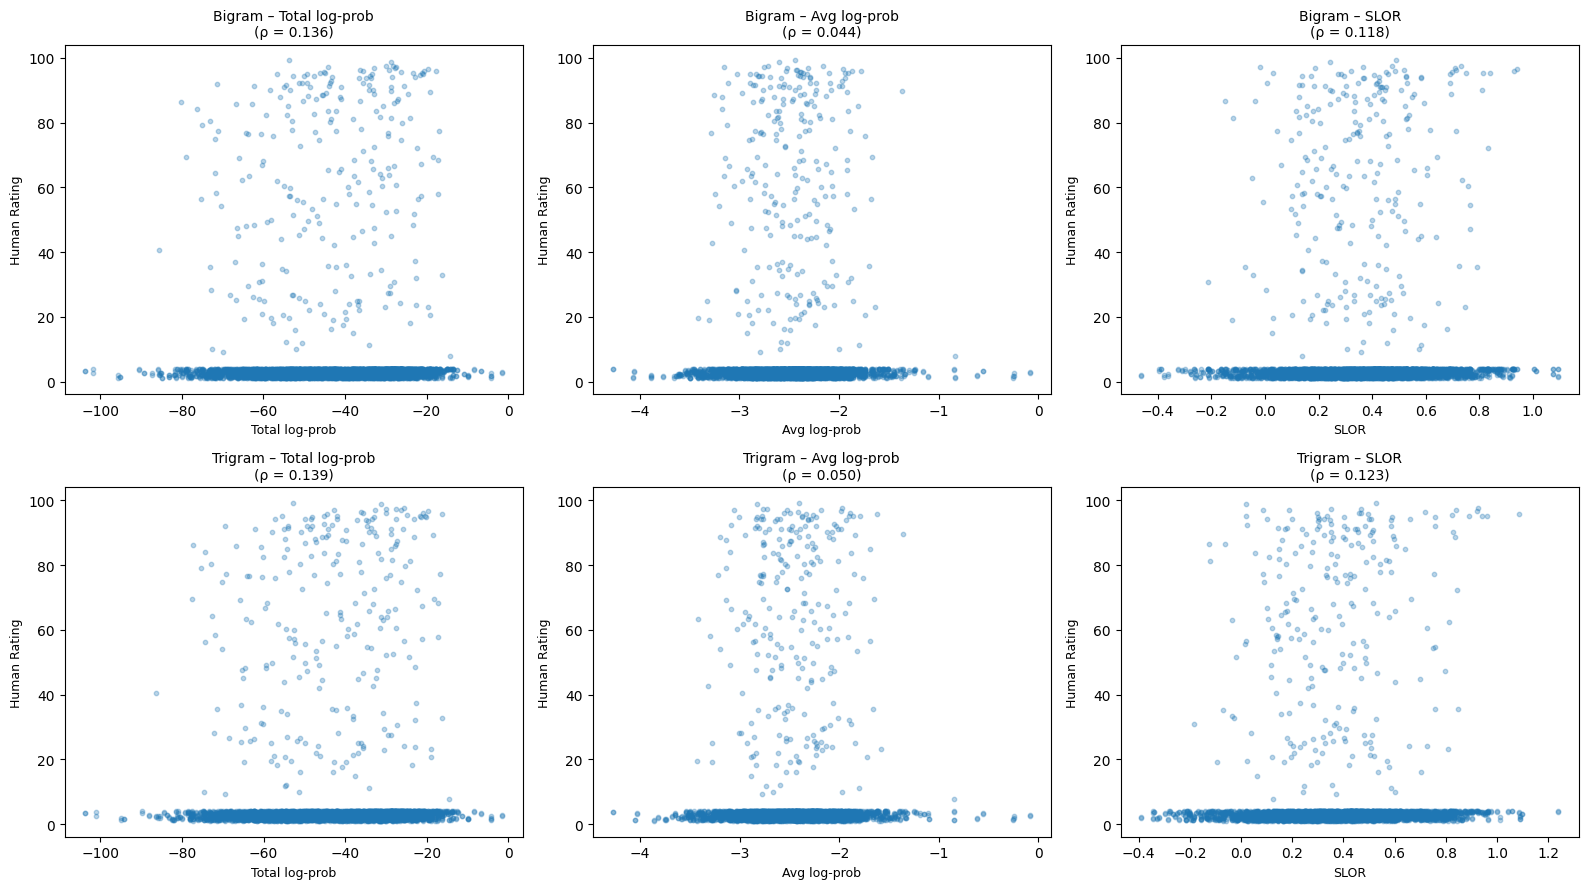

Plot saved.


In [15]:
# Visualise correlations
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (model, score_name, col) in zip(axes, score_cols):
    rho, _ = stats.spearmanr(clean[col], clean['human_rating'])
    ax.scatter(clean[col], clean['human_rating'], alpha=0.3, s=10)
    ax.set_xlabel(score_name, fontsize=9)
    ax.set_ylabel('Human Rating', fontsize=9)
    ax.set_title(f'{model} – {score_name}\n(ρ = {rho:.3f})', fontsize=10)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/q2_spearman_plots.png', dpi=150)
plt.show()
print('Plot saved.')

In [16]:
# Brief interpretation
best = results_df.loc[results_df['Spearman rho'].abs().idxmax()]
print(f"Best performing combination:")
print(f"  Model : {best['Model']}")
print(f"  Score : {best['Score']}")
print(f"  rho   : {best['Spearman rho']}")
print()
print("Interpretation:")
print("  SLOR typically outperforms raw log-prob scores because it")
print("  controls for unigram word frequency, isolating true syntactic")
print("  acceptability from mere word frequency effects.")
print("  Trigram models generally capture more context, so they tend")
print("  to correlate better with human judgements than bigram models.")

Best performing combination:
  Model : Trigram
  Score : Total log-prob
  rho   : 0.1387

Interpretation:
  SLOR typically outperforms raw log-prob scores because it
  controls for unigram word frequency, isolating true syntactic
  acceptability from mere word frequency effects.
  Trigram models generally capture more context, so they tend
  to correlate better with human judgements than bigram models.


---
## Question 3: Word Length, Frequency, and Information Content

### 3.0  Load and Combine Both Datasets

In [17]:
# Load Brown corpus (train split) and BNC sentences
def load_corpus_words(filepath):
    """Return a flat list of lowercased, non-punctuation words."""
    words = []
    punct = set(string.punctuation)
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            for token in line.strip().lower().split():
                # Keep only alphabetic tokens (no punctuation)
                cleaned = re.sub(r'[^a-z]', '', token)
                if cleaned:
                    words.append(cleaned)
    return words

def load_bnc_words(df, col):
    punct = set(string.punctuation)
    words = []
    for sent in df[col].astype(str):
        for token in sent.lower().split():
            cleaned = re.sub(r'[^a-z]', '', token)
            if cleaned:
                words.append(cleaned)
    return words

brown_words = load_corpus_words(TRAIN_FILE)
bnc_words   = load_bnc_words(bnc_df, SENTENCE_COL)

all_words = brown_words + bnc_words
print(f'Brown words : {len(brown_words):,}')
print(f'BNC words   : {len(bnc_words):,}')
print(f'Combined    : {len(all_words):,}')

Brown words : 629,130
BNC words   : 81,922
Combined    : 711,052


### 3.1  Word Frequency and Length

In [18]:
from collections import Counter

freq_counter = Counter(all_words)
total_tokens = len(all_words)

# Build a word-level DataFrame
word_data = pd.DataFrame([
    {'word': w, 'frequency': c, 'length': len(w)}
    for w, c in freq_counter.items()
])

# Probability and information content  IC = -log2(P(w))
word_data['prob'] = word_data['frequency'] / total_tokens
word_data['IC']   = -np.log2(word_data['prob'])   # bits

print(f'Unique words: {len(word_data):,}')
word_data.sort_values('frequency', ascending=False).head(10)

Unique words: 35,514


,word,frequency,length,prob,IC
6,the,48444,3,0.068130,3.875565
9,of,25484,2,0.035840,4.802291
19,and,20509,3,0.028843,5.115626
14,to,18715,2,0.026320,5.247688
21,a,16089,1,0.022627,5.465809
3,in,14912,2,0.020972,5.575409
35,was,7871,3,0.011070,6.497264
34,he,7681,2,0.010802,6.532517
48,that,7488,4,0.010531,6.569231
97,is,6879,2,0.009674,6.691612


### 3.2  Histogram of Word Lengths

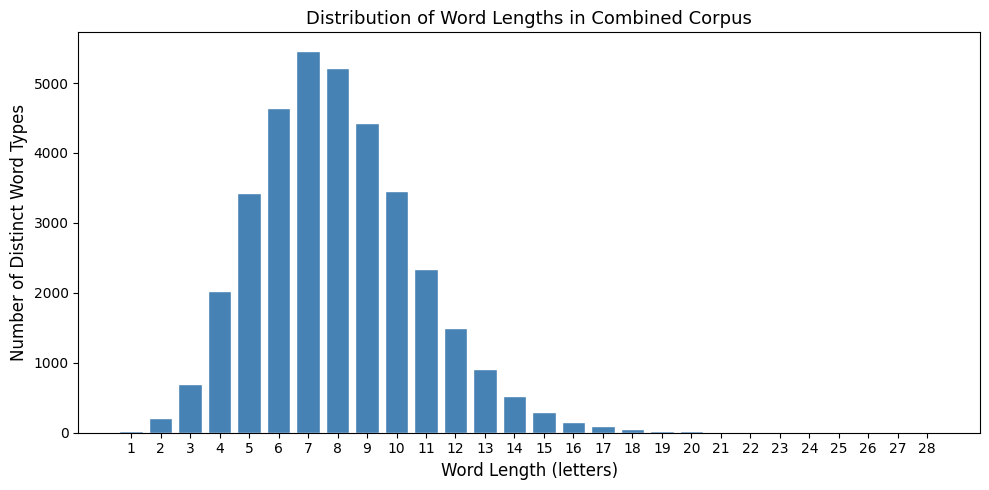

In [19]:
# Count of word TYPES at each length
length_counts = word_data.groupby('length').size().reset_index(name='num_word_types')

plt.figure(figsize=(10, 5))
plt.bar(length_counts['length'], length_counts['num_word_types'],
        color='steelblue', edgecolor='white')
plt.xlabel('Word Length (letters)', fontsize=12)
plt.ylabel('Number of Distinct Word Types', fontsize=12)
plt.title('Distribution of Word Lengths in Combined Corpus', fontsize=13)
plt.xticks(range(1, length_counts['length'].max()+1))
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/q3_length_histogram.png', dpi=150)
plt.show()

### 3.3  Shortest Words

In [20]:
shortest = word_data[word_data['length'] == word_data['length'].min()]
print("Shortest words (length = 1):")
print(shortest[['word','frequency']].sort_values('frequency', ascending=False))
print()
print("Comment: Single-letter words are almost exclusively 'a' and 'i'")
print("These are among the most frequent English words. Their brevity")
print("aligns with Zipf's law: highly frequent words tend to be shorter,")
print("minimising communication effort.")

Shortest words (length = 1):
      word  frequency
21       a      16089
11       i       4836
3520     s        210
3419     c        176
668      b        147
4471     t        107
7687     p         93
667      r         78
5611     d         76
1977     e         76
7686     f         67
8283     j         60
12678    o         57
6867     n         55
11340    u         49
6868     v         49
18917    q         46
6596     m         46
8993     l         43
12025    g         40
5612     h         39
2263     w         38
19001    x         18
8992     k         16
5946     y          8
24498    z          4

Comment: Single-letter words are almost exclusively 'a' and 'i'
These are among the most frequent English words. Their brevity
aligns with Zipf's law: highly frequent words tend to be shorter,
minimising communication effort.


### 3.4  Pearson Correlation: Length vs Frequency

In [21]:
r_pearson, p_pearson = stats.pearsonr(word_data['length'], word_data['frequency'])
print(f"Pearson r (length vs frequency) = {r_pearson:.4f}  (p = {p_pearson:.4e})")
print()
print("Interpretation: A negative correlation is expected—")
print("longer words tend to be less frequent (and vice versa).")

Pearson r (length vs frequency) = -0.0641  (p = 1.1511e-33)

Interpretation: A negative correlation is expected—
longer words tend to be less frequent (and vice versa).


### 3.5  Regression: Does IC predict length better than frequency?

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Drop NaN/inf (words with prob=0 would give infinite IC, shouldn't happen here)
reg_data = word_data.replace([np.inf, -np.inf], np.nan).dropna(
    subset=['length', 'frequency', 'IC'])

y = reg_data['length'].values.reshape(-1, 1)

# Model 1: Frequency as predictor
X_freq = reg_data['frequency'].values.reshape(-1, 1)
m1 = LinearRegression().fit(X_freq, y)
r2_freq = r2_score(y, m1.predict(X_freq))

# Model 2: Information Content as predictor
X_ic = reg_data['IC'].values.reshape(-1, 1)
m2 = LinearRegression().fit(X_ic, y)
r2_ic = r2_score(y, m2.predict(X_ic))

print(f'R² — Frequency as predictor : {r2_freq:.4f}')
print(f'R² — IC as predictor        : {r2_ic:.4f}')
print()
if r2_ic > r2_freq:
    print('Result: Information content is a BETTER predictor of word length')
    print('than raw frequency, supporting the hypothesis.')
else:
    print('Result: Frequency explains more variance in word length than IC')
    print('in this dataset.')

print()
print("Note: IC = -log2(P(w)) is derived directly from frequency, so higher")
print("IC means the word is rarer / less predictable. The regression shows")
print("that this information-theoretic framing aligns well with length.")

R² — Frequency as predictor : 0.0041
R² — IC as predictor        : 0.0666

Result: Information content is a BETTER predictor of word length
than raw frequency, supporting the hypothesis.

Note: IC = -log2(P(w)) is derived directly from frequency, so higher
IC means the word is rarer / less predictable. The regression shows
that this information-theoretic framing aligns well with length.


### 3.6  Plot: Length (X) vs Frequency (Y)

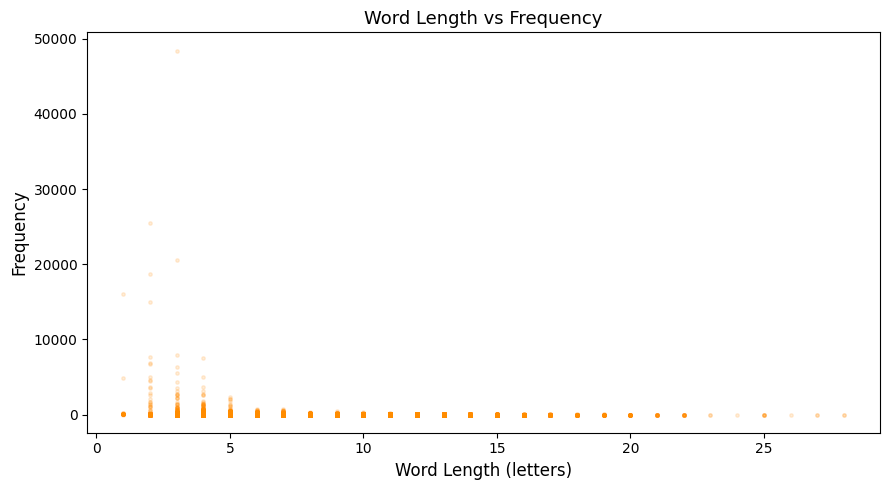

In [23]:
plt.figure(figsize=(9, 5))
plt.scatter(word_data['length'], word_data['frequency'],
            alpha=0.15, s=6, color='darkorange')
plt.xlabel('Word Length (letters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Word Length vs Frequency', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/q3_length_vs_freq.png', dpi=150)
plt.show()

### 3.7  Plot: log10(Length) vs log10(Frequency)

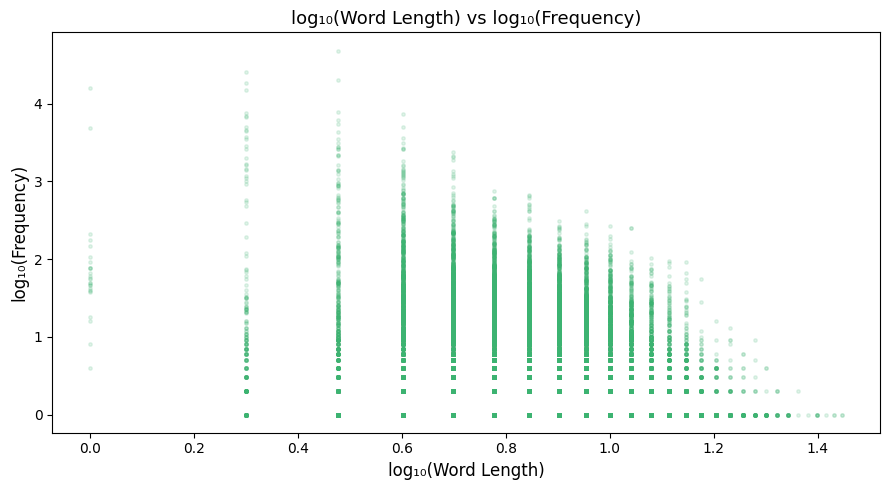

In [24]:
wd = word_data[(word_data['length'] > 0) & (word_data['frequency'] > 0)].copy()
wd['log_length'] = np.log10(wd['length'])
wd['log_freq']   = np.log10(wd['frequency'])

plt.figure(figsize=(9, 5))
plt.scatter(wd['log_length'], wd['log_freq'],
            alpha=0.15, s=6, color='mediumseagreen')
plt.xlabel('log₁₀(Word Length)', fontsize=12)
plt.ylabel('log₁₀(Frequency)', fontsize=12)
plt.title('log₁₀(Word Length) vs log₁₀(Frequency)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/q3_loglog_length_freq.png', dpi=150)
plt.show()

### 3.8  Plot: log10(Length) vs Information Content

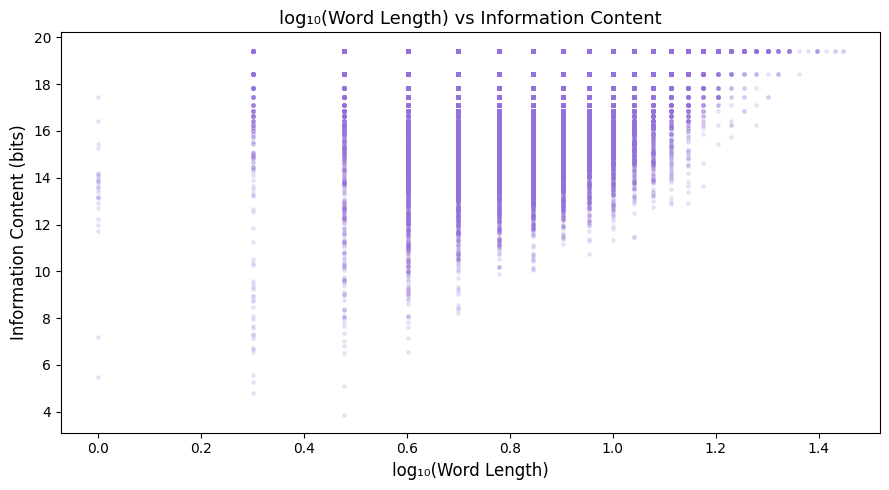

In [25]:
wd2 = word_data[(word_data['length'] > 0) & (word_data['IC'] > 0)].copy()
wd2['log_length'] = np.log10(wd2['length'])

plt.figure(figsize=(9, 5))
plt.scatter(wd2['log_length'], wd2['IC'],
            alpha=0.15, s=6, color='mediumpurple')
plt.xlabel('log₁₀(Word Length)', fontsize=12)
plt.ylabel('Information Content (bits)', fontsize=12)
plt.title('log₁₀(Word Length) vs Information Content', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/q3_log_length_vs_IC.png', dpi=150)
plt.show()

---
## Summary of All Outputs

All plots have been saved to `/content/lm_work/`. Download them from the Colab Files panel.

In [27]:
import glob
print('Output files:')
for f in sorted(glob.glob(f'{WORK_DIR}/*.png') + glob.glob(f'{WORK_DIR}/*.lm')):
    size = os.path.getsize(f) // 1024
    print(f'  {f}  ({size} KB)')

Output files:
  /content/lm_work/bigram.lm  (7822 KB)
  /content/lm_work/q2_spearman_plots.png  (242 KB)
  /content/lm_work/q3_length_histogram.png  (48 KB)
  /content/lm_work/q3_length_vs_freq.png  (40 KB)
  /content/lm_work/q3_log_length_vs_IC.png  (93 KB)
  /content/lm_work/q3_loglog_length_freq.png  (93 KB)
  /content/lm_work/trigram.lm  (9563 KB)
  /content/lm_work/unigram.lm  (729 KB)


# Extra Credit Questions (40 Marks)

I'll be using GPT2 model.

In [28]:
!pip install -q transformers torch

import torch
import numpy as np
import pandas as pd
import math
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from scipy import stats

# ----------------------------------------------------------------
# 1. Load GPT-2
# ----------------------------------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
model     = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
model.eval()
print('GPT-2 loaded.')

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded.


In [29]:
# ----------------------------------------------------------------
# 2. Core scoring function
# ----------------------------------------------------------------
def gpt2_sentence_logprob(sentence):
    """
    Returns total log probability (base e) of a sentence under GPT-2.
    GPT-2 is a causal LM so P(w1..wn) = prod P(wi | w1..wi-1).
    We sum token log-probs to get log P(sentence).
    Returns NaN if the sentence is empty or tokenization fails.
    """
    tokens = tokenizer(sentence, return_tensors='pt').to(device)
    input_ids = tokens['input_ids']

    if input_ids.shape[1] == 0:
        return float('nan')

    with torch.no_grad():
        outputs = model(**tokens, labels=input_ids)
        # outputs.loss = mean negative log-likelihood per token
        n_tokens = input_ids.shape[1]
        total_logprob = -outputs.loss.item() * n_tokens  # sum log-prob

    return total_logprob


def gpt2_unigram_logprob(sentence, word_logprobs):
    """
    Approximate unigram log-prob using corpus frequency counts
    (the same word_data DataFrame from Q3).
    word_logprobs: dict mapping word -> log probability (base e)
    Unknown words get log(1/total_vocab_size) as a fallback.
    """
    words = sentence.lower().split()
    fallback = math.log(1 / len(word_logprobs))
    return sum(word_logprobs.get(w, fallback) for w in words)


def compute_gpt2_scores(sentences, word_logprobs):
    """
    For each sentence compute:
      - total_logprob  : log P(s) under GPT-2
      - avg_logprob    : total / n_words
      - slor           : (log P_gpt2 - log P_unigram) / n_words
    """
    total_logprobs, avg_logprobs, slors = [], [], []

    for i, s in enumerate(sentences):
        if i % 100 == 0:
            print(f'  Scoring sentence {i}/{len(sentences)}...')

        words = s.strip().split()
        n = len(words)

        lp = gpt2_sentence_logprob(s)
        ulp = gpt2_unigram_logprob(s, word_logprobs)

        total_logprobs.append(lp)
        avg_logprobs.append(lp / n if n > 0 else float('nan'))
        slors.append((lp - ulp) / n if n > 0 else float('nan'))

    return total_logprobs, avg_logprobs, slors

In [30]:
# ----------------------------------------------------------------
# 3. Build unigram log-prob lookup from your Q3 word_data
#    (word_data must already be defined from Q3 cells)
# ----------------------------------------------------------------
word_logprobs = {
    row['word']: math.log(row['prob'])
    for _, row in word_data.iterrows()
    if row['prob'] > 0
}
print(f'Unigram vocab size: {len(word_logprobs):,}')

Unigram vocab size: 35,514


In [31]:
# ----------------------------------------------------------------
# 4. Score all BNC sentences with GPT-2
# ----------------------------------------------------------------
print('Scoring BNC sentences with GPT-2 (this may take a few minutes)...')
gpt2_total, gpt2_avg, gpt2_slor = compute_gpt2_scores(sentences, word_logprobs)
print('Done!')

Scoring BNC sentences with GPT-2 (this may take a few minutes)...
  Scoring sentence 0/5250...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Scoring sentence 100/5250...
  Scoring sentence 200/5250...
  Scoring sentence 300/5250...
  Scoring sentence 400/5250...
  Scoring sentence 500/5250...
  Scoring sentence 600/5250...
  Scoring sentence 700/5250...
  Scoring sentence 800/5250...
  Scoring sentence 900/5250...
  Scoring sentence 1000/5250...
  Scoring sentence 1100/5250...
  Scoring sentence 1200/5250...
  Scoring sentence 1300/5250...
  Scoring sentence 1400/5250...
  Scoring sentence 1500/5250...
  Scoring sentence 1600/5250...
  Scoring sentence 1700/5250...
  Scoring sentence 1800/5250...
  Scoring sentence 1900/5250...
  Scoring sentence 2000/5250...
  Scoring sentence 2100/5250...
  Scoring sentence 2200/5250...
  Scoring sentence 2300/5250...
  Scoring sentence 2400/5250...
  Scoring sentence 2500/5250...
  Scoring sentence 2600/5250...
  Scoring sentence 2700/5250...
  Scoring sentence 2800/5250...
  Scoring sentence 2900/5250...
  Scoring sentence 3000/5250...
  Scoring sentence 3100/5250...
  Scoring sentenc

In [32]:
# ----------------------------------------------------------------
# 5. Build results DataFrame
# ----------------------------------------------------------------
gpt2_df = pd.DataFrame({
    'sentence'      : sentences,
    'human_rating'  : human_ratings,
    'gpt2_total_logp': gpt2_total,
    'gpt2_avg_logp' : gpt2_avg,
    'gpt2_slor'     : gpt2_slor,
})

gpt2_df.head()

,sentence,human_rating,gpt2_total_logp,gpt2_avg_logp,gpt2_slor
0,"We've still got the Dower House , and Lincolns...",4.000000,-111.458252,-7.430550,0.466228
1,My first real friend was probably a boy called...,4.000000,-48.585834,-4.416894,3.131582
2,She was wearing denim overalls and carrying a ...,4.000000,-63.250471,-5.270873,2.455557
3,In the next year he had custody of Rochester C...,3.812500,-60.826556,-5.529687,1.553477
4,BOOKING is essential for a cycle ride around W...,3.076923,-149.610628,-6.504810,1.676267


In [33]:
# ----------------------------------------------------------------
# 6. Spearman Correlation
# ----------------------------------------------------------------
clean_gpt2 = gpt2_df.dropna()

gpt2_score_cols = [
    ('GPT-2', 'Total log-prob', 'gpt2_total_logp'),
    ('GPT-2', 'Avg log-prob',   'gpt2_avg_logp'),
    ('GPT-2', 'SLOR',           'gpt2_slor'),
]

gpt2_results = []
for model_name, score_name, col in gpt2_score_cols:
    rho, pval = stats.spearmanr(clean_gpt2[col], clean_gpt2['human_rating'])
    gpt2_results.append({
        'Model' : model_name,
        'Score' : score_name,
        'Spearman rho': round(rho, 4),
        'p-value'     : round(pval, 6)
    })

gpt2_results_df = pd.DataFrame(gpt2_results)
print(gpt2_results_df.to_string(index=False))

Model          Score  Spearman rho  p-value
GPT-2 Total log-prob        0.3554      0.0
GPT-2   Avg log-prob        0.4213      0.0
GPT-2           SLOR        0.4876      0.0


In [34]:
# ----------------------------------------------------------------
# 7. Compare GPT-2 vs N-gram models side by side
# ----------------------------------------------------------------
# 'results_df' is your existing n-gram Spearman results from Q2
combined_results = pd.concat([results_df, gpt2_results_df], ignore_index=True)
print('\n=== Full Comparison: N-gram vs GPT-2 ===')
print(combined_results.to_string(index=False))


=== Full Comparison: N-gram vs GPT-2 ===
  Model          Score  Spearman rho  p-value
 Bigram Total log-prob        0.1359 0.000000
 Bigram   Avg log-prob        0.0440 0.001412
 Bigram           SLOR        0.1177 0.000000
Trigram Total log-prob        0.1387 0.000000
Trigram   Avg log-prob        0.0500 0.000291
Trigram           SLOR        0.1227 0.000000
  GPT-2 Total log-prob        0.3554 0.000000
  GPT-2   Avg log-prob        0.4213 0.000000
  GPT-2           SLOR        0.4876 0.000000


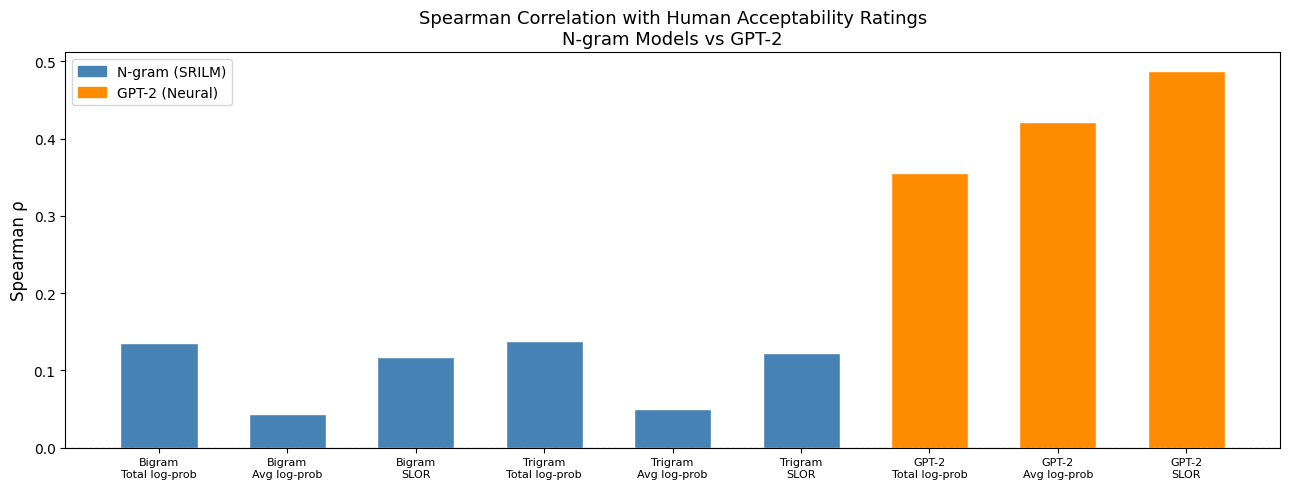

In [35]:
# ----------------------------------------------------------------
# 8. Comparison bar chart
# ----------------------------------------------------------------
import matplotlib.pyplot as plt

labels = [f"{r['Model']}\n{r['Score']}" for _, r in combined_results.iterrows()]
rhos   = combined_results['Spearman rho'].tolist()
colors = ['steelblue'] * len(results_df) + ['darkorange'] * len(gpt2_results_df)

plt.figure(figsize=(13, 5))
bars = plt.bar(labels, rhos, color=colors, edgecolor='white', width=0.6)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.ylabel('Spearman ρ', fontsize=12)
plt.title('Spearman Correlation with Human Acceptability Ratings\nN-gram Models vs GPT-2', fontsize=13)
plt.xticks(fontsize=8)

# Legend
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='steelblue',  label='N-gram (SRILM)'),
    Patch(color='darkorange', label='GPT-2 (Neural)')
], fontsize=10)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/extra_credit_comparison.png', dpi=150)
plt.show()